# Introduction

This notebook implements a complete machine learning pipeline for analyzing simulated genomic SNP datasets used in the project **“Genetics SNP Data Simulation: Predicting a Binary Outcome in Simulated Genomics Data.”**  
The datasets contain thousands of SNP features, including both predictive and non-predictive variants, and represent different genetic association patterns such as additive effects, epistasis, and heterogeneity.

The goal of this code is to:

- **Load and preprocess** all 8 datasets (4 basic + 4 challenge)  
- **Handle missing values**, class label issues, and high-dimensional SNP features  
- **Train multiple machine learning models** (Logistic Regression, Random Forest, XGBoost)  
- **Evaluate model performance** using accuracy, ROC-AUC, PR-AUC, and confusion matrices  
- **Generate visual outputs** including ROC curves, PR curves, and feature importance plots  
- **Compare models** across datasets to determine which algorithms best capture different genetic association structures  

This notebook is designed to be **modular, reproducible, and scalable**.  
Each dataset runs through the same standardized analysis pipeline, enabling clear comparison of model performance across diverse genomic architectures.

In [82]:
import os
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    precision_recall_curve,
    average_precision_score,
    confusion_matrix,
    classification_report
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Try to import XGBoost if installed
try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    print("⚠️ xgboost not installed; XGBoost model will be skipped.")
    HAS_XGB = False

# Make plots a bit nicer
plt.rcParams["figure.dpi"] = 120

# Folder where your 8 real datasets live
# Example: r"C:\Users\YourName\Documents\gametes_data"
DATA_ROOT = Path(r"C:\Users\apandiyan1\Documents\Academics\Fall 2025\CSC 590 - Final Project\Simulated_Genomic_Binary-Class\Simulated Genomic Binary-Class\data\Directory")  # <--- change this to your folder if needed

# Where to save all results (figures + metrics)
RESULTS_ROOT = Path("./results_final")
RESULTS_ROOT.mkdir(exist_ok=True)

print("DATA_ROOT:", DATA_ROOT.resolve())
print("RESULTS_ROOT:", RESULTS_ROOT.resolve())


DATA_ROOT: C:\Users\apandiyan1\Documents\Academics\Fall 2025\CSC 590 - Final Project\Simulated_Genomic_Binary-Class\Simulated Genomic Binary-Class\data\Directory
RESULTS_ROOT: C:\Users\apandiyan1\Documents\Academics\Fall 2025\CSC 590 - Final Project\Project\Archive\results_final


In [83]:
PENETRANCE_COLS = ["M0P1", "M1P2", "M2P3", "M3P4"]

def load_real_dataset(path):
    """
    Load ANY of the 8 real datasets:
      - 100-feature (clean whitespace)
      - 10,000-feature (fixed-width)
    And correctly extract X, y.
    """
    fname = str(path)

    # Detect challenge dataset by filename OR column count
    is_challenge = ("10000" in fname) or ("with_NA" in fname)

    if is_challenge:
        print("Detected challenge dataset → using fixed-width reader (fwf).")
        df = pd.read_fwf(path, na_values=["NA", "N/A", "?", " "], dtype=str)
    else:
        df = pd.read_csv(path, sep=r"\s+", engine="python", dtype=str)

    print("Initial shape:", df.shape)

    # Convert everything numeric where possible
    df = df.apply(pd.to_numeric, errors="ignore")

    # === FIXED: Correct penetrance columns ===
    pen_cols = [c for c in df.columns if c.startswith("M") and "P" in c]
    if pen_cols:
        print("Dropping penetrance columns:", pen_cols)
        df = df.drop(columns=pen_cols)

    # === FIXED: Use REAL 'Class' column ===
    if "Class" not in df.columns:
        raise ValueError("❌ This dataset has no 'Class' column!")

    # Convert Class to int
    df["Class"] = pd.to_numeric(df["Class"], errors="coerce")

    before = len(df)
    df = df.dropna(subset=["Class"])
    after = len(df)
    print(f"Dropped {before - after} rows with missing Class.")

    # Final split
    y = df["Class"].astype(int)
    X = df.drop(columns=["Class"])

    print(f"Final shape: X={X.shape}, y={y.shape}")
    return X, y, list(X.columns)

In [84]:
def plot_roc_curve(y_true, y_proba, out_path: Path, title: str):
    from sklearn.metrics import roc_curve

    fpr, tpr, _ = roc_curve(y_true, y_proba)
    auc = roc_auc_score(y_true, y_proba)

    plt.figure()
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(title)
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def plot_pr_curve(y_true, y_proba, out_path: Path, title: str):
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    ap = average_precision_score(y_true, y_proba)

    plt.figure()
    plt.plot(recall, precision, label=f"AP = {ap:.3f}")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title(title)
    plt.legend(loc="lower left")
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def plot_confusion_matrix_cm(y_true, y_pred, out_path: Path, title: str):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure()
    plt.imshow(cm, interpolation="nearest")
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(2)
    plt.xticks(tick_marks, ["0", "1"])
    plt.yticks(tick_marks, ["0", "1"])
    plt.xlabel("Predicted")
    plt.ylabel("True")

    # annotate
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(
                j, i,
                cm[i, j],
                ha="center",
                va="center",
                color="white" if cm[i, j] > thresh else "black",
            )

    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def plot_feature_importance(importances, feature_names, out_path: Path, title: str, top_k: int = 20):
    imp = np.array(importances)
    names = np.array(feature_names)

    idx = np.argsort(imp)[::-1][:top_k]
    top_imp = imp[idx]
    top_names = names[idx]

    plt.figure(figsize=(6, 6))
    plt.barh(range(len(top_imp)), top_imp[::-1])
    plt.yticks(range(len(top_imp)), top_names[::-1], fontsize=6)
    plt.xlabel("Importance")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.show()
    plt.close()


In [85]:
def train_models_on_dataset(X, y, out_dir: Path, dataset_name: str):
    """
    Train Logistic Regression, Random Forest, and (optionally) XGBoost.
    Save:
      • ROC curves
      • PR curves
      • Confusion matrices
      • Feature importance plots
      • metrics.csv with basic scores
    """
    out_dir.mkdir(exist_ok=True)

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.20, stratify=y, random_state=42
    )

    # Standardize for linear model
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    models = {}

    # Logistic Regression
    logreg = LogisticRegression(max_iter=1000, n_jobs=-1)
    models["LogReg"] = ("scaled", logreg)

    # Random Forest
    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )
    models["RandomForest"] = ("raw", rf)

    # XGBoost (if available)
    if HAS_XGB:
        xgb = XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            subsample=0.8,
            colsample_bytree=0.8,
            random_state=42,
            tree_method="hist",
            eval_metric="logloss"
        )
        models["XGBoost"] = ("raw", xgb)

    metrics_rows = []

    for model_name, (input_type, model) in models.items():
        print(f"  -> Training {model_name} on {dataset_name}...")

        if input_type == "scaled":
            X_tr, X_te = X_train_scaled, X_test_scaled
        else:
            X_tr, X_te = X_train.values, X_test.values

        # Fit
        model.fit(X_tr, y_train)

        # Predict
        y_pred = model.predict(X_te)
        if hasattr(model, "predict_proba"):
            y_proba = model.predict_proba(X_te)[:, 1]
        elif hasattr(model, "decision_function"):
            scores = model.decision_function(X_te)
            # map scores to [0,1] via sigmoid
            y_proba = 1 / (1 + np.exp(-scores))
        else:
            # last fallback: use predicted labels (not ideal)
            y_proba = y_pred.astype(float)

        # Metrics
        acc = accuracy_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        ap = average_precision_score(y_test, y_proba)

        print(f"     Accuracy = {acc:.4f} | ROC-AUC = {roc_auc:.4f} | AP = {ap:.4f}")

        # Save metrics row
        metrics_rows.append({
            "dataset": dataset_name,
            "model": model_name,
            "accuracy": acc,
            "roc_auc": roc_auc,
            "avg_precision": ap
        })

        # Classification report text file
        report = classification_report(y_test, y_pred, digits=4)
        with open(out_dir / f"{model_name}_classification_report.txt", "w") as f:
            f.write(report)

        # Plots
        plot_roc_curve(
            y_test, y_proba,
            out_dir / f"{model_name}_roc_curve.png",
            title=f"{dataset_name} — {model_name} ROC"
        )

        plot_pr_curve(
            y_test, y_proba,
            out_dir / f"{model_name}_pr_curve.png",
            title=f"{dataset_name} — {model_name} PR Curve"
        )

        plot_confusion_matrix_cm(
            y_test, y_pred,
            out_dir / f"{model_name}_confusion_matrix.png",
            title=f"{dataset_name} — {model_name} Confusion Matrix"
        )

        # Feature importance (if available)
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        elif isinstance(model, LogisticRegression):
            importances = np.abs(model.coef_[0])
        else:
            importances = None

        if importances is not None:
            plot_feature_importance(
                importances,
                X_train.columns,
                out_dir / f"{model_name}_feature_importance_top20.png",
                title=f"{dataset_name} — {model_name} Feature Importance (Top 20)",
                top_k=20
            )

            # Save full importance table
            fi_df = pd.DataFrame({
                "feature": X_train.columns,
                "importance": importances
            }).sort_values("importance", ascending=False)
            fi_df.to_csv(out_dir / f"{model_name}_feature_importance.csv", index=False)

    # Save metrics for all models in this dataset
    metrics_df = pd.DataFrame(metrics_rows)
    metrics_df.to_csv(out_dir / "metrics_summary.csv", index=False)

    return metrics_df


In [86]:
# Adjust file names here if yours differ.
DATASETS = {
    "4-wayAdditive_100feat": "4-wayAdditive_100feat.txt",
    "2Additive_2-wayEpi_100feat": "2Additive_2-wayEpi_100feat.txt",
    "2-wayEpi_100feat": "2-wayEpi_100feat.txt",
    "4-wayHeterogeneous_100feat": "4-wayHeterogeneous_100feat.txt",

    # Large 10,000-feature sets WITH NA
    "4-wayAdditive_10000feat_with_NA": "4-wayAdditive_10000feat_with_NA.txt",
    "2Additive_2-wayEpi_10000feat_with_NA": "2Additive_2-wayEpi_10000feat_with_NA.txt",
    "2-wayEpi_10000feat_with_NA": "2-wayEpi_10000feat_with_NA.txt",
    "4-wayHeterogeneous_10000feat_with_NA": "4-wayHeterogeneous_10000feat_with_NA.txt",
}

print("==== Checking dataset paths ====")
for name, fname in DATASETS.items():
    full_path = DATA_ROOT / fname
    print(f"{name:40s} ->  {full_path.exists()}")


==== Checking dataset paths ====
4-wayAdditive_100feat                    ->  True
2Additive_2-wayEpi_100feat               ->  True
2-wayEpi_100feat                         ->  True
4-wayHeterogeneous_100feat               ->  True
4-wayAdditive_10000feat_with_NA          ->  True
2Additive_2-wayEpi_10000feat_with_NA     ->  True
2-wayEpi_10000feat_with_NA               ->  True
4-wayHeterogeneous_10000feat_with_NA     ->  True



==== Running All 8 Datasets ====


### Running 4-wayAdditive_100feat ###
--- Loading: 4-wayAdditive_100feat.txt ---
Initial shape: (1000, 101)
Last 10 columns: ['N91', 'N92', 'N93', 'N94', 'N95', 'M0P1', 'M1P2', 'M2P3', 'M3P4', 'Class']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 96), y=(1000,)
  -> Training LogReg on 4-wayAdditive_100feat...
     Accuracy = 0.4950 | ROC-AUC = 0.5141 | AP = 0.5294


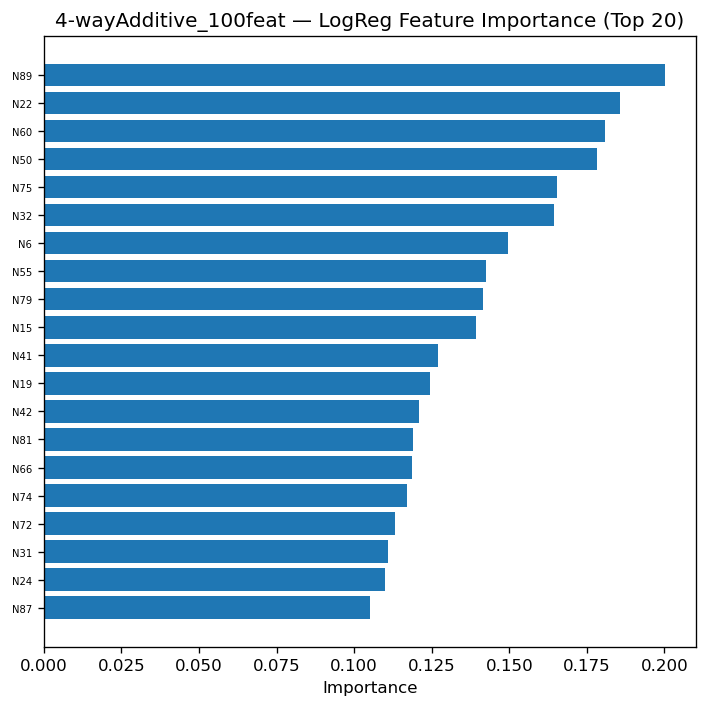

  -> Training RandomForest on 4-wayAdditive_100feat...
     Accuracy = 0.4700 | ROC-AUC = 0.4587 | AP = 0.4610


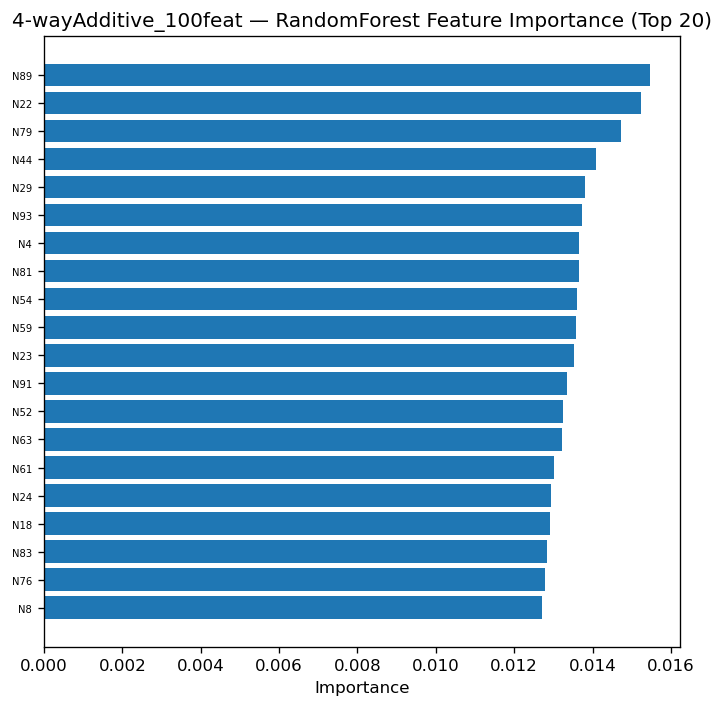

  -> Training XGBoost on 4-wayAdditive_100feat...
     Accuracy = 0.4900 | ROC-AUC = 0.4582 | AP = 0.4679


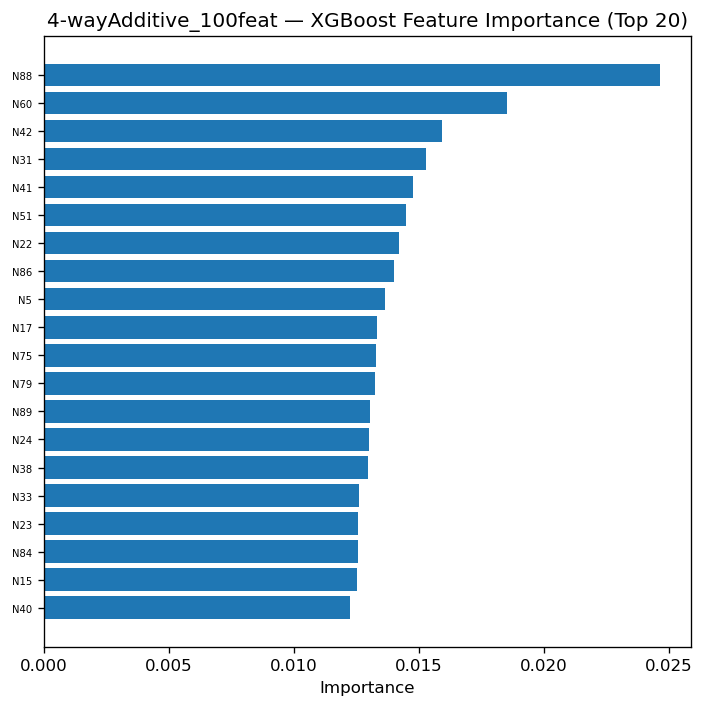


### Running 2Additive_2-wayEpi_100feat ###
--- Loading: 2Additive_2-wayEpi_100feat.txt ---
Initial shape: (1000, 101)
Last 10 columns: ['N91', 'N92', 'N93', 'N94', 'N95', 'M0P1', 'M0P2', 'M1P3', 'M1P4', 'Class']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 96), y=(1000,)
  -> Training LogReg on 2Additive_2-wayEpi_100feat...
     Accuracy = 0.4650 | ROC-AUC = 0.4525 | AP = 0.4846


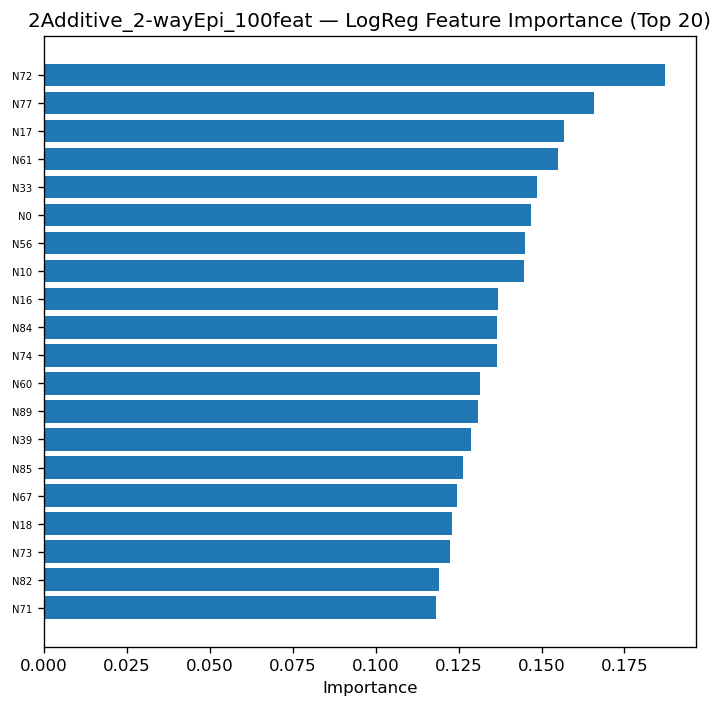

  -> Training RandomForest on 2Additive_2-wayEpi_100feat...
     Accuracy = 0.4950 | ROC-AUC = 0.4599 | AP = 0.5057


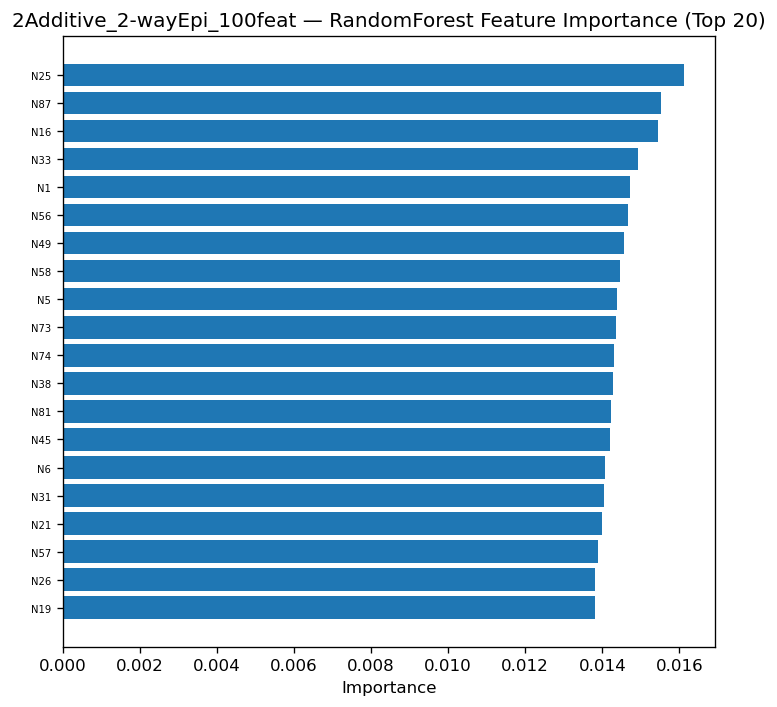

  -> Training XGBoost on 2Additive_2-wayEpi_100feat...
     Accuracy = 0.4600 | ROC-AUC = 0.4405 | AP = 0.4910


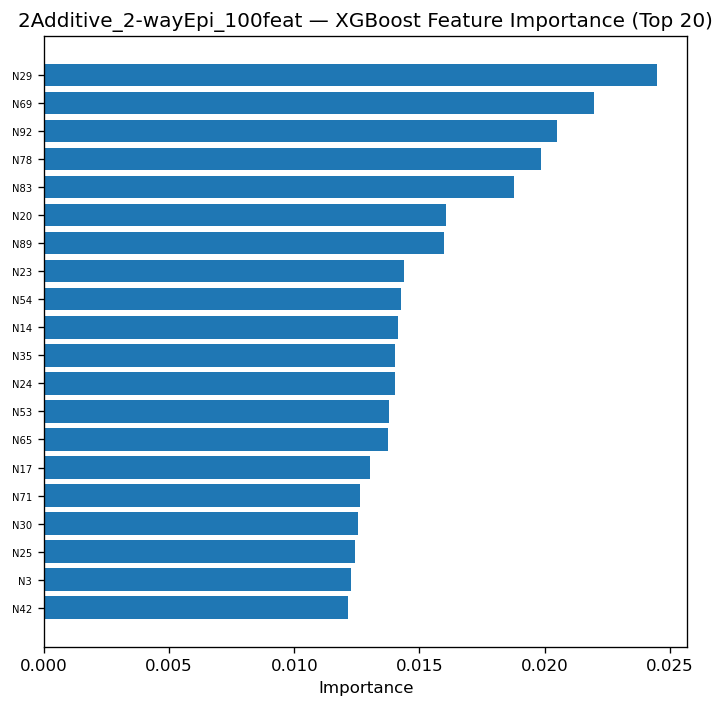


### Running 2-wayEpi_100feat ###
--- Loading: 2-wayEpi_100feat.txt ---
Initial shape: (1000, 101)
Last 10 columns: ['N91', 'N92', 'N93', 'N94', 'N95', 'N96', 'N97', 'M0P1', 'M0P2', 'Class']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 98), y=(1000,)
  -> Training LogReg on 2-wayEpi_100feat...
     Accuracy = 0.5100 | ROC-AUC = 0.4992 | AP = 0.4861


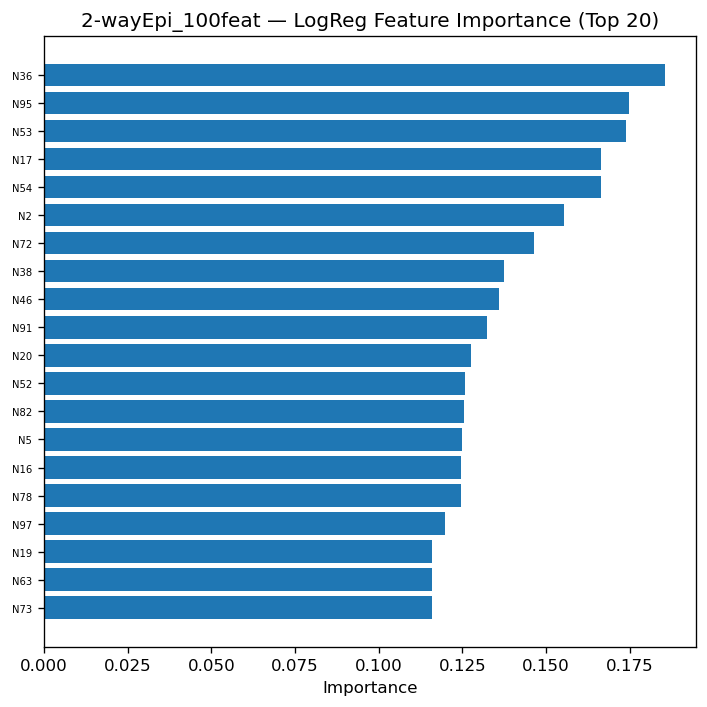

  -> Training RandomForest on 2-wayEpi_100feat...
     Accuracy = 0.5100 | ROC-AUC = 0.4890 | AP = 0.4881


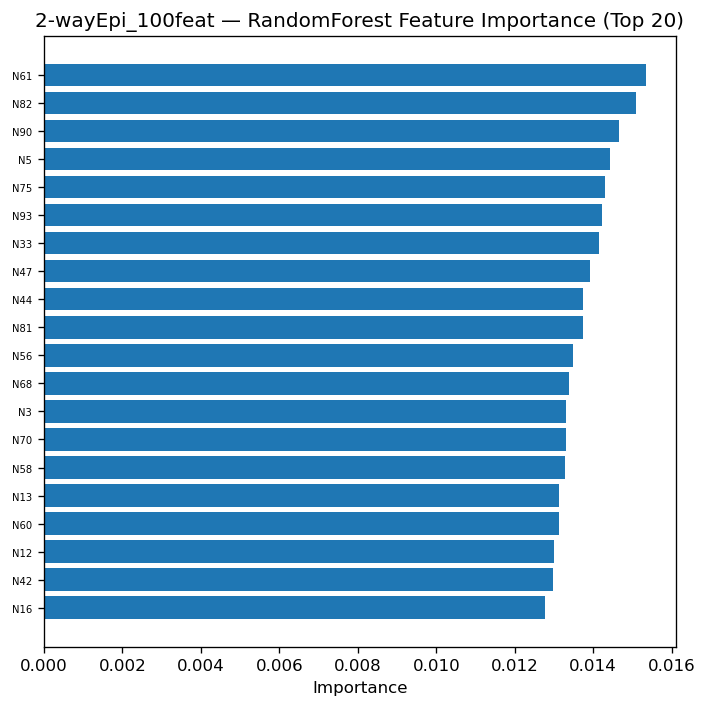

  -> Training XGBoost on 2-wayEpi_100feat...
     Accuracy = 0.4950 | ROC-AUC = 0.4705 | AP = 0.4909


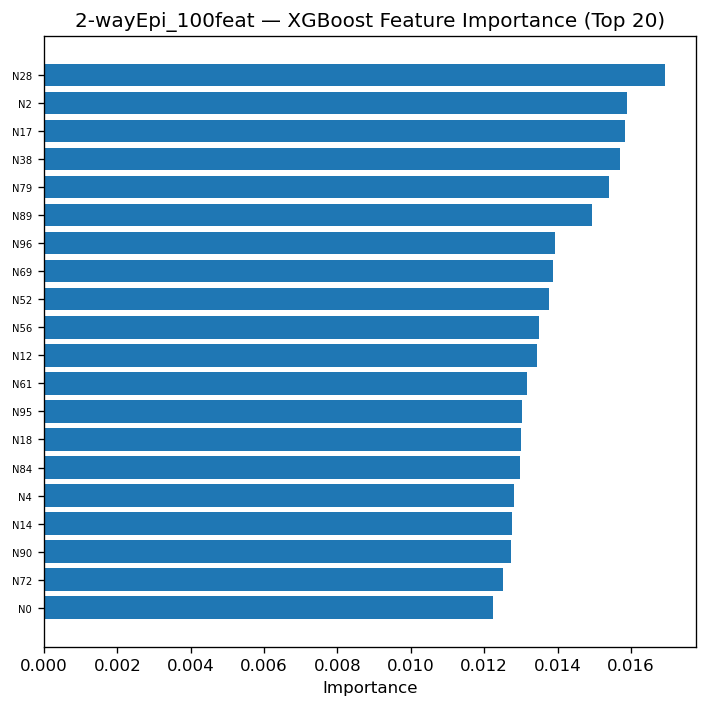


### Running 4-wayHeterogeneous_100feat ###
--- Loading: 4-wayHeterogeneous_100feat.txt ---
Initial shape: (1000, 101)
Last 10 columns: ['N91', 'N92', 'N93', 'N94', 'N95', 'M0P1', 'M1P2', 'M2P3', 'M3P4', 'Class']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 96), y=(1000,)
  -> Training LogReg on 4-wayHeterogeneous_100feat...
     Accuracy = 0.4650 | ROC-AUC = 0.4575 | AP = 0.4687


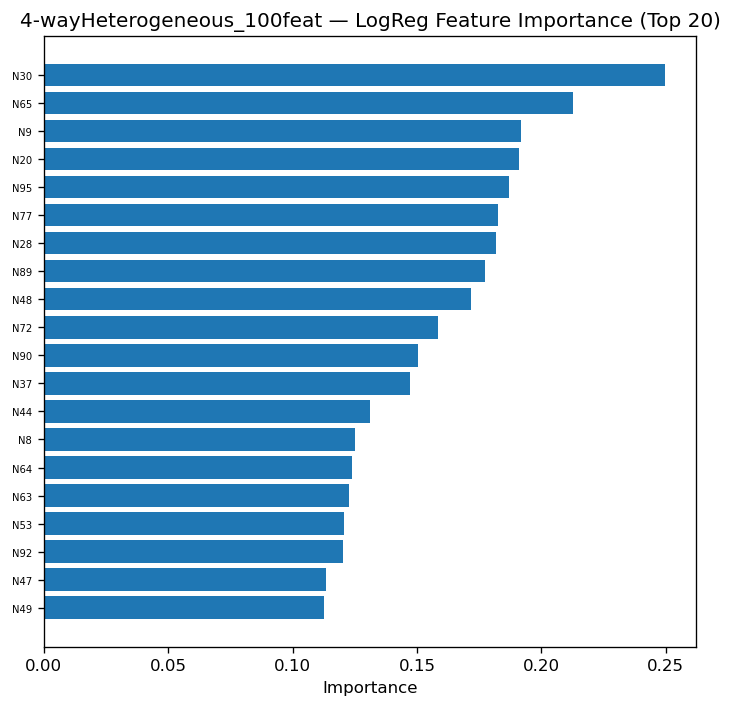

  -> Training RandomForest on 4-wayHeterogeneous_100feat...
     Accuracy = 0.4850 | ROC-AUC = 0.4560 | AP = 0.4633


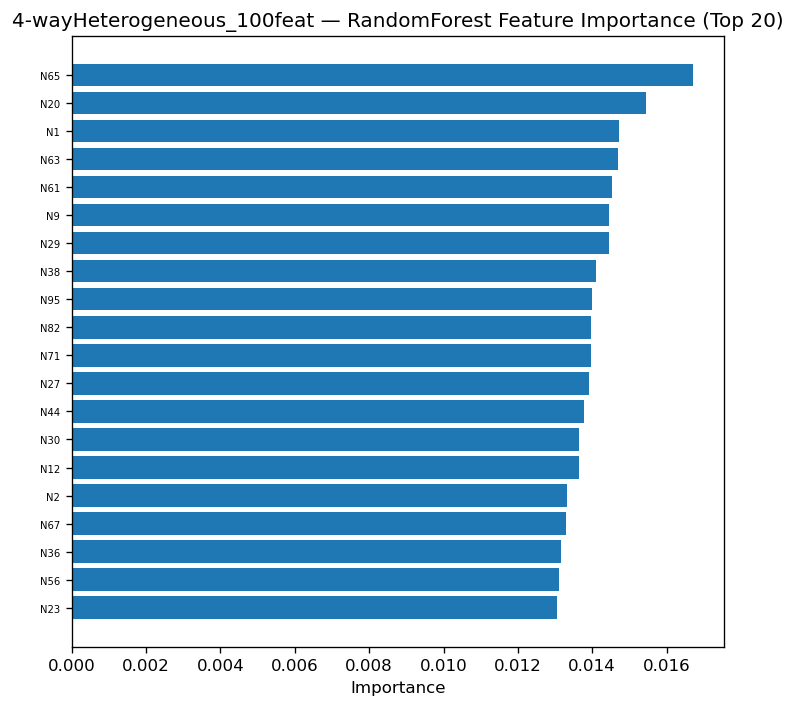

  -> Training XGBoost on 4-wayHeterogeneous_100feat...
     Accuracy = 0.4850 | ROC-AUC = 0.4435 | AP = 0.4757


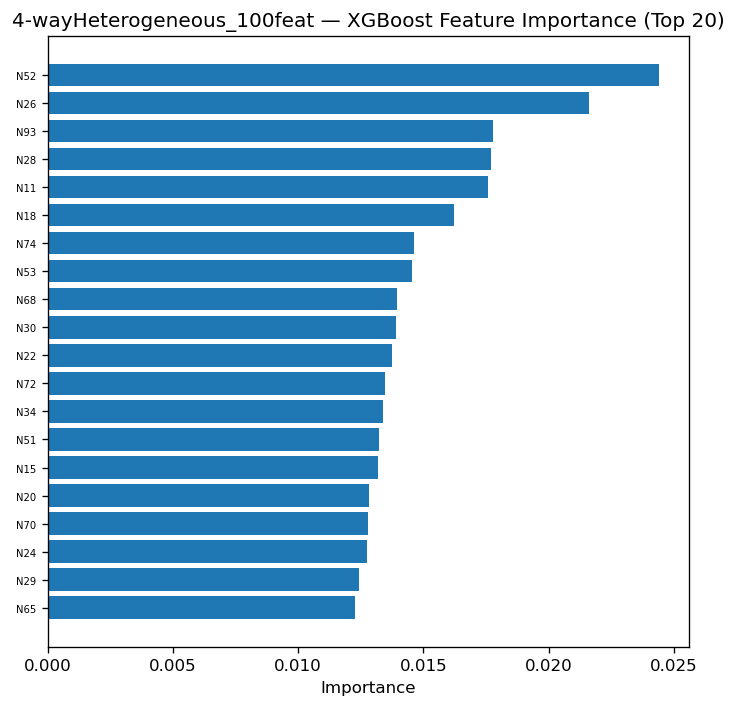


### Running 4-wayAdditive_10000feat_with_NA ###
--- Loading: 4-wayAdditive_10000feat_with_NA.txt ---
Initial shape: (1000, 10005)
Last 10 columns: ['N9995', 'N9996', 'N9997', 'N9998', 'N9999', 'Class', 'M0P1', 'M1P2', 'M2P3', 'M3P4']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 10000), y=(1000,)
  -> Training LogReg on 4-wayAdditive_10000feat_with_NA...
     Accuracy = 0.9950 | ROC-AUC = 0.2312 | AP = 0.0065


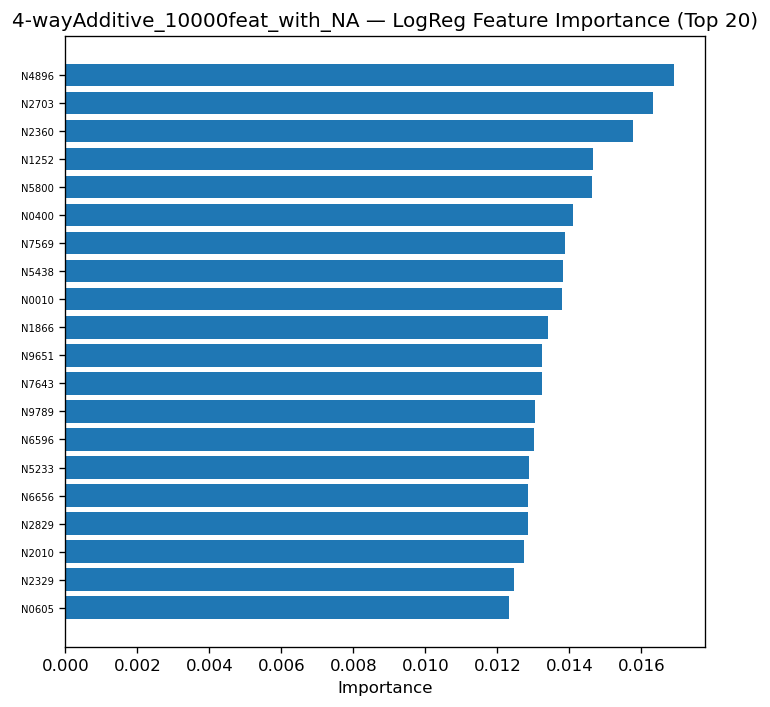

  -> Training RandomForest on 4-wayAdditive_10000feat_with_NA...
     Accuracy = 0.9950 | ROC-AUC = 0.7412 | AP = 0.0145


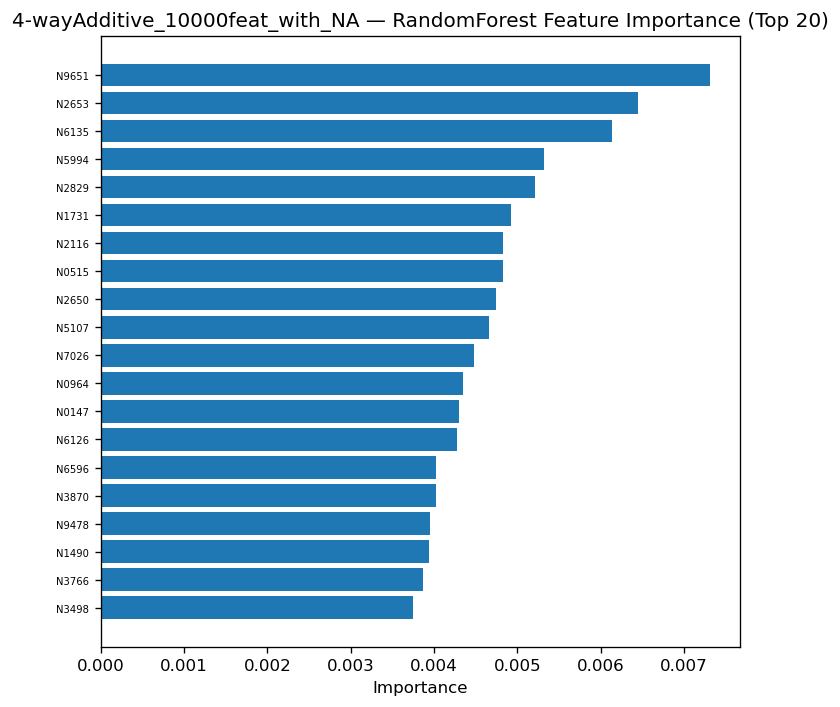

  -> Training XGBoost on 4-wayAdditive_10000feat_with_NA...
     Accuracy = 0.9950 | ROC-AUC = 0.5829 | AP = 0.0119


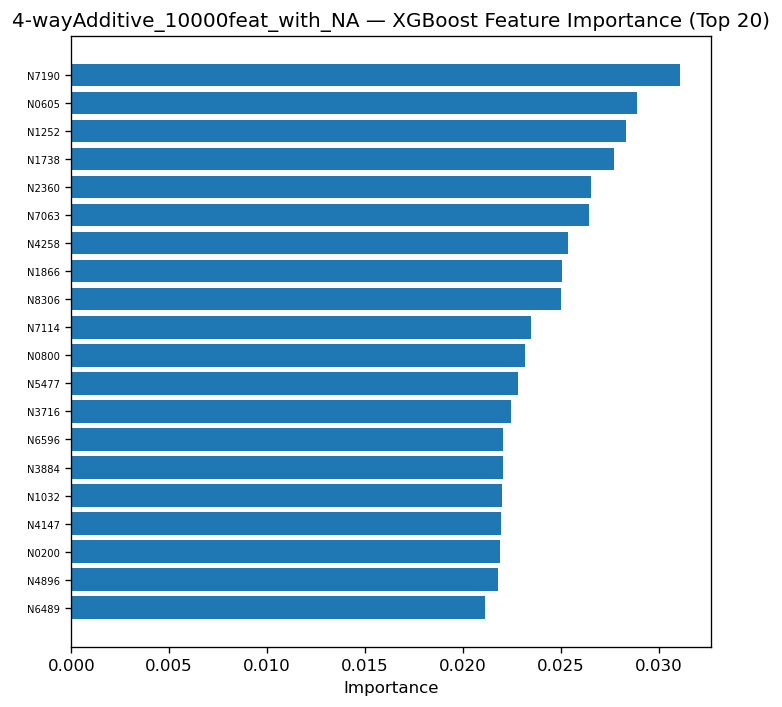


### Running 2Additive_2-wayEpi_10000feat_with_NA ###
--- Loading: 2Additive_2-wayEpi_10000feat_with_NA.txt ---
Initial shape: (1000, 10005)
Last 10 columns: ['N9995', 'N9996', 'N9997', 'N9998', 'N9999', 'Class', 'M0P1', 'M1P2', 'M2P3', 'M3P4']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 10000), y=(1000,)
  -> Training LogReg on 2Additive_2-wayEpi_10000feat_with_NA...
     Accuracy = 0.7200 | ROC-AUC = 0.4796 | AP = 0.2595


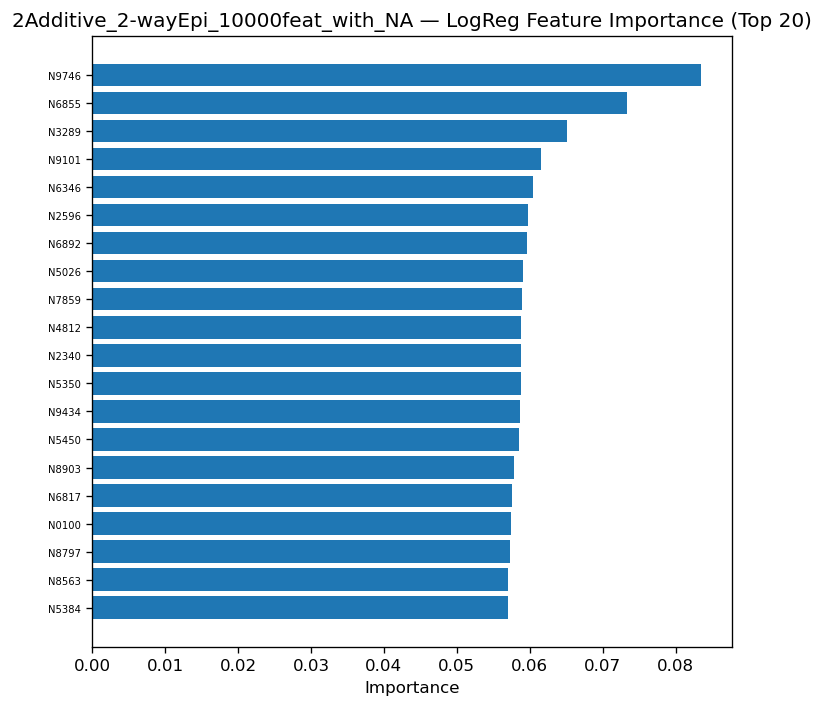

  -> Training RandomForest on 2Additive_2-wayEpi_10000feat_with_NA...
     Accuracy = 0.7300 | ROC-AUC = 0.5347 | AP = 0.3028


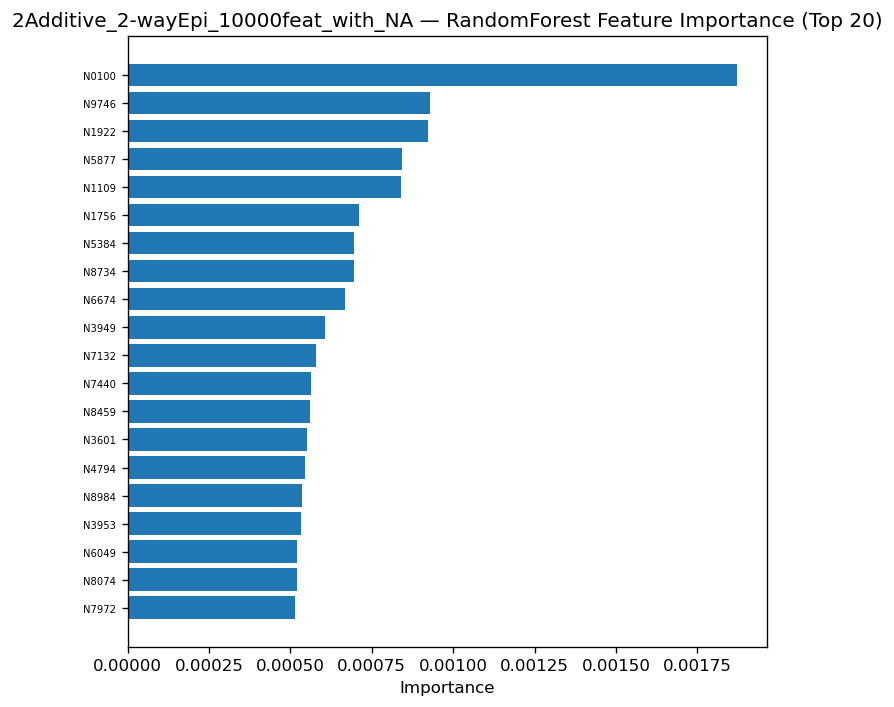

  -> Training XGBoost on 2Additive_2-wayEpi_10000feat_with_NA...
     Accuracy = 0.7400 | ROC-AUC = 0.6878 | AP = 0.4890


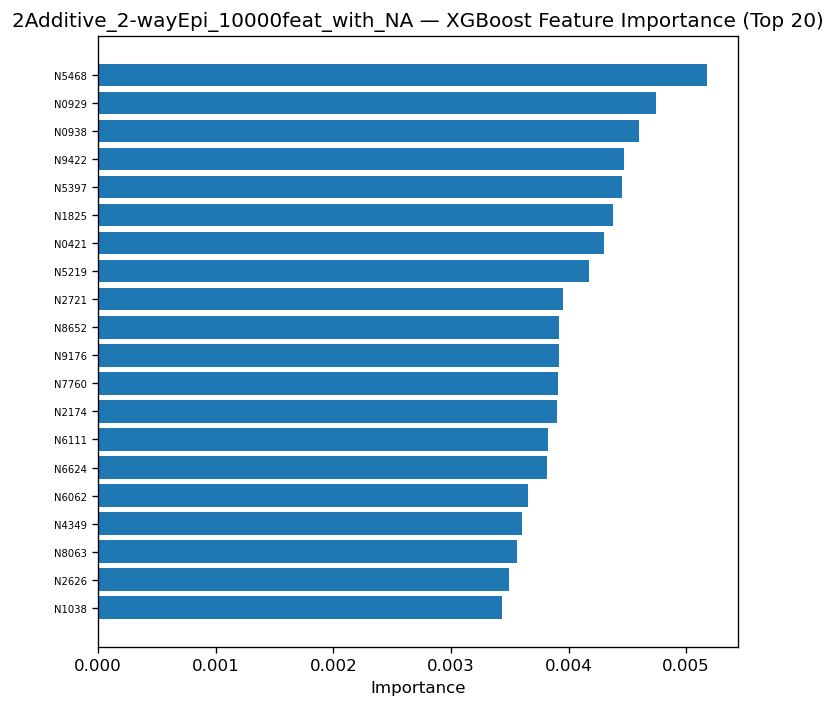


### Running 2-wayEpi_10000feat_with_NA ###
--- Loading: 2-wayEpi_10000feat_with_NA.txt ---
Initial shape: (1000, 10003)
Last 10 columns: ['N9993', 'N9994', 'N9995', 'N9996', 'N9997', 'N9998', 'N9999', 'Class', 'M0P1', 'M1P2']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 10000), y=(1000,)
  -> Training LogReg on 2-wayEpi_10000feat_with_NA...
     Accuracy = 0.4750 | ROC-AUC = 0.4688 | AP = 0.4694


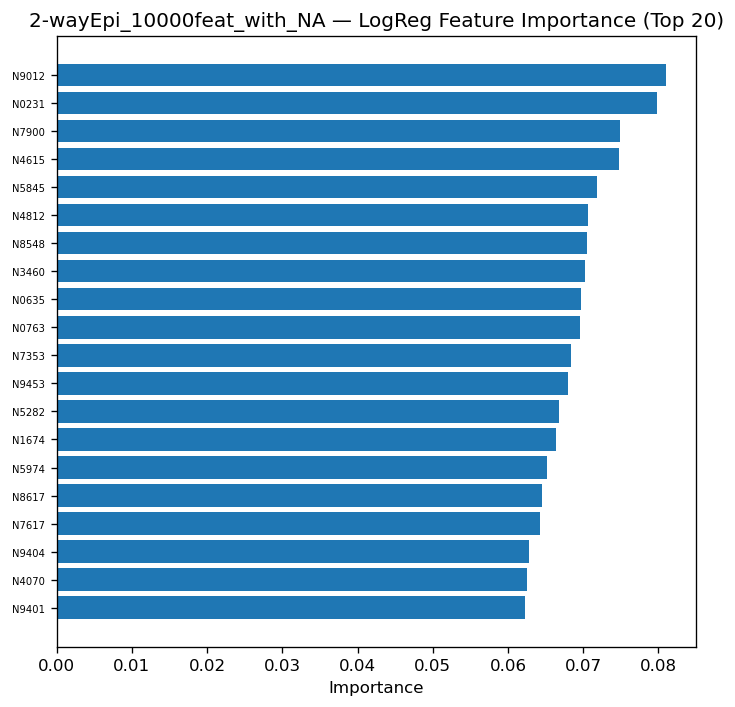

  -> Training RandomForest on 2-wayEpi_10000feat_with_NA...
     Accuracy = 0.5150 | ROC-AUC = 0.5675 | AP = 0.5357


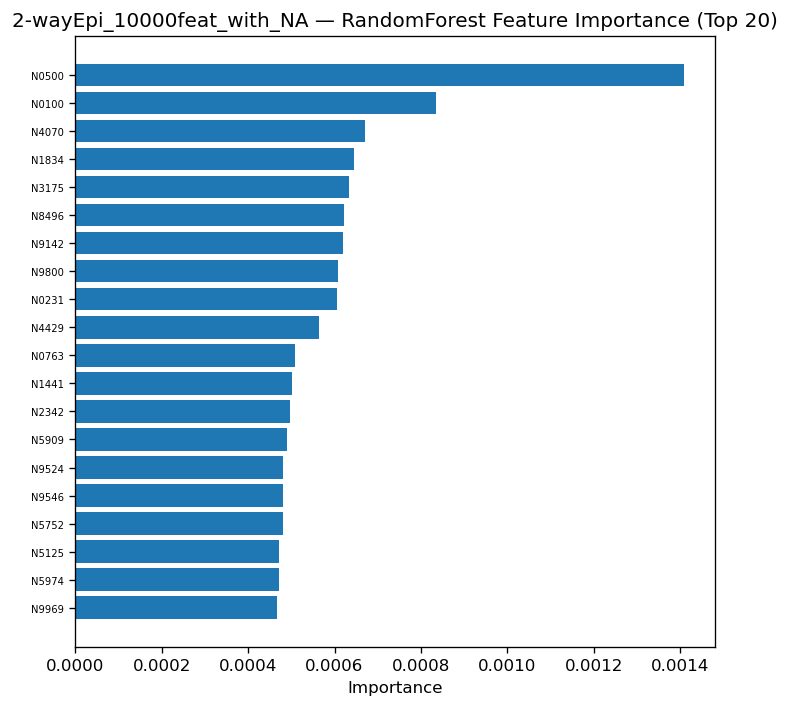

  -> Training XGBoost on 2-wayEpi_10000feat_with_NA...
     Accuracy = 0.9650 | ROC-AUC = 0.9958 | AP = 0.9957


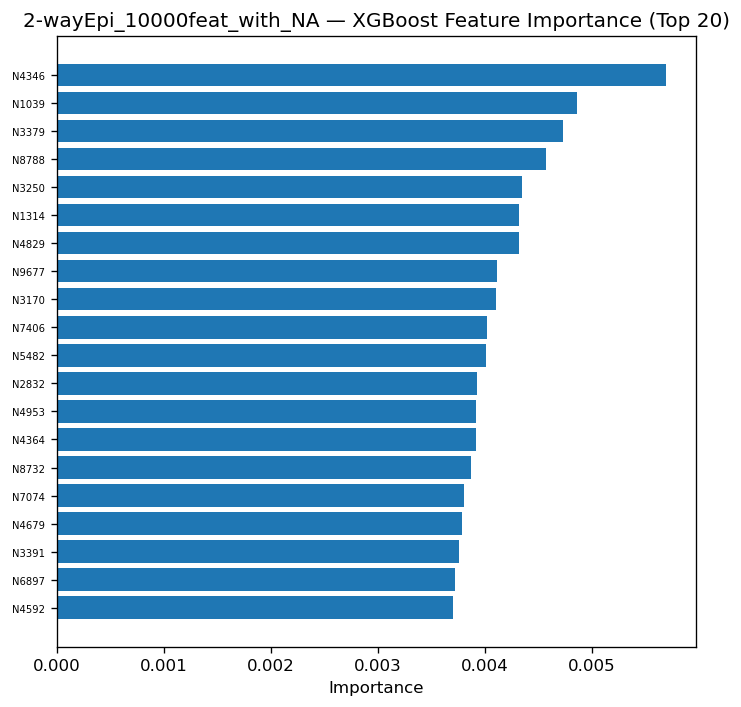


### Running 4-wayHeterogeneous_10000feat_with_NA ###
--- Loading: 4-wayHeterogeneous_10000feat_with_NA.txt ---
Initial shape: (1000, 10005)
Last 10 columns: ['N9995', 'N9996', 'N9997', 'N9998', 'N9999', 'Class', 'M0P1', 'M1P2', 'M2P3', 'M3P4']
Dropped 0 rows with missing Class.
Final shape: X=(1000, 10000), y=(1000,)
  -> Training LogReg on 4-wayHeterogeneous_10000feat_with_NA...
     Accuracy = 0.7400 | ROC-AUC = 0.4815 | AP = 0.2423


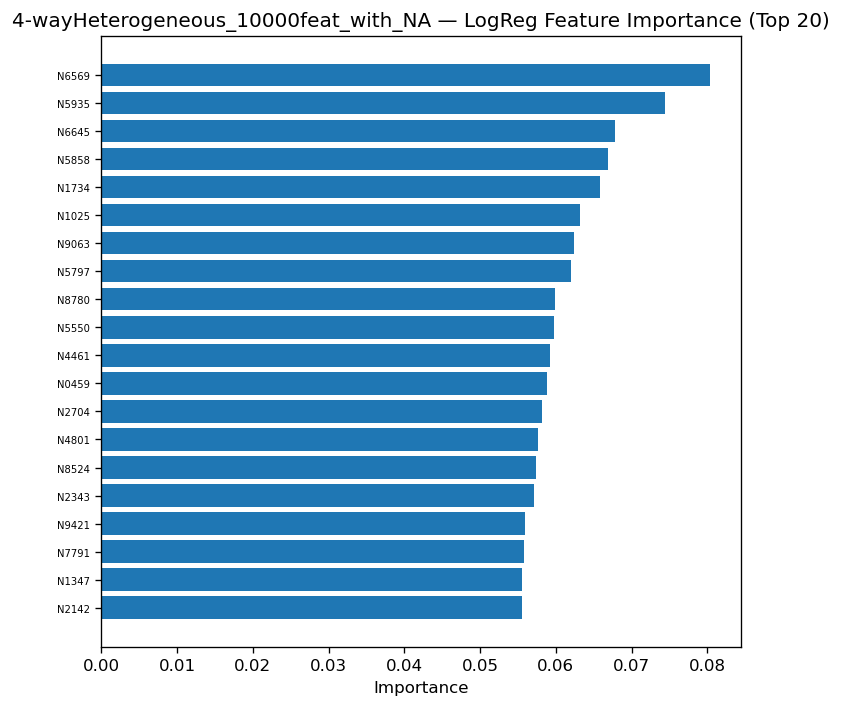

  -> Training RandomForest on 4-wayHeterogeneous_10000feat_with_NA...
     Accuracy = 0.7600 | ROC-AUC = 0.4659 | AP = 0.2237


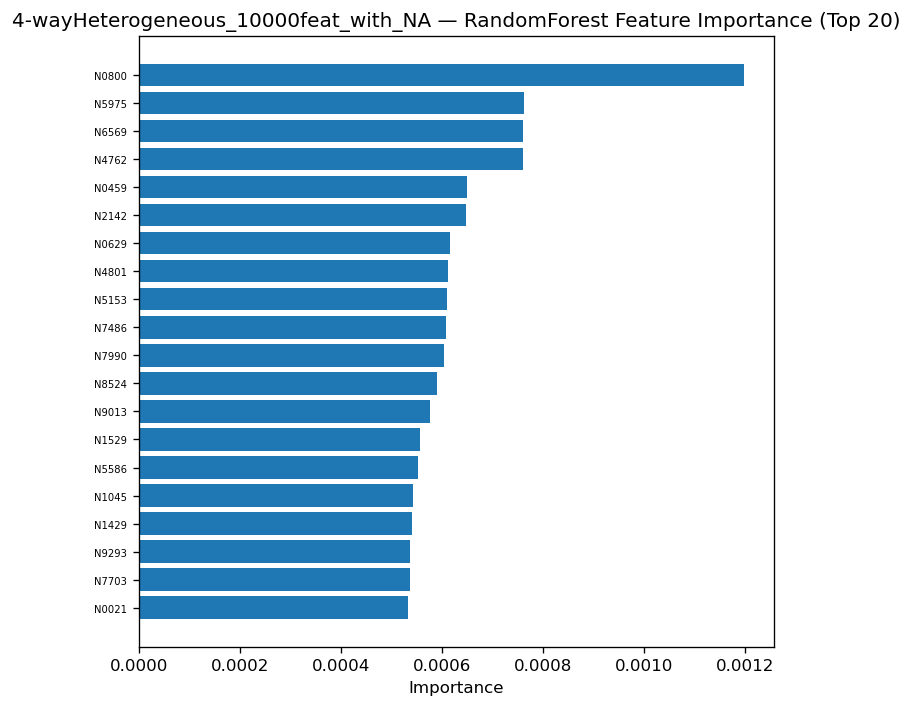

  -> Training XGBoost on 4-wayHeterogeneous_10000feat_with_NA...
     Accuracy = 0.7600 | ROC-AUC = 0.6334 | AP = 0.4268


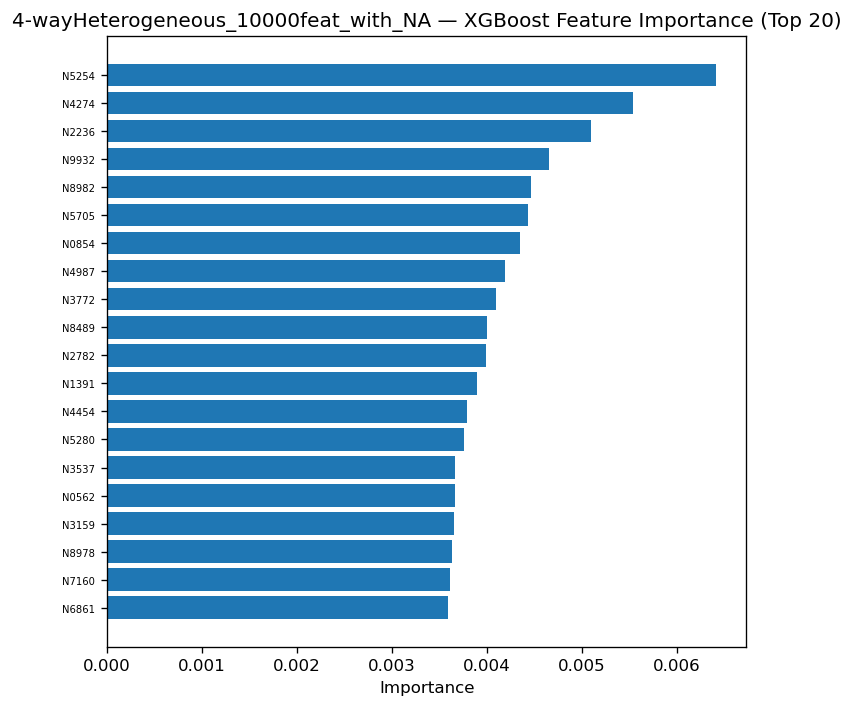

,dataset,model,accuracy,roc_auc,avg_precision
0,4-wayAdditive_100feat,LogReg,0.495,0.514100,0.529362
1,4-wayAdditive_100feat,RandomForest,0.470,0.458750,0.460973
2,4-wayAdditive_100feat,XGBoost,0.490,0.458200,0.467939
3,2Additive_2-wayEpi_100feat,LogReg,0.465,0.452500,0.484566
4,2Additive_2-wayEpi_100feat,RandomForest,0.495,0.459950,0.505718
5,2Additive_2-wayEpi_100feat,XGBoost,0.460,0.440500,0.490985
6,2-wayEpi_100feat,LogReg,0.510,0.499200,0.486061
7,2-wayEpi_100feat,RandomForest,0.510,0.489000,0.488122
8,2-wayEpi_100feat,XGBoost,0.495,0.470500,0.490902
9,4-wayHeterogeneous_100feat,LogReg,0.465,0.457500,0.468706


In [87]:
all_metrics = []

print("\n==== Running All 8 Datasets ====\n")

for dataset_name, filename in DATASETS.items():
    path = DATA_ROOT / filename

    if not path.exists():
        print(f"⚠️ Skipping {dataset_name}: file not found at {path}")
        continue

    print(f"\n### Running {dataset_name} ###")
    # Load
    X, y, feature_names = load_real_dataset(path)

    if len(X) == 0:
        print(f"⚠️ Skipping {dataset_name}: no usable samples after loading.")
        continue

    # Output directory for this dataset
    out_dir = RESULTS_ROOT / dataset_name

    # Train and save all diagrams
    metrics_df = train_models_on_dataset(X, y, out_dir, dataset_name)
    all_metrics.append(metrics_df)

# Combine all results in one CSV
if all_metrics:
    all_metrics_df = pd.concat(all_metrics, ignore_index=True)
    all_metrics_df.to_csv(RESULTS_ROOT / "ALL_DATASETS_metrics_summary.csv", index=False)
    display(all_metrics_df)
else:
    print("No datasets were successfully processed.")
